Dataset loaded. Shape: (200, 5)
Missing values:
 Customer_ID       0
Gender            0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64
Duplicates: 0
Data types:
 Customer_ID        int64
Gender            object
Age                int64
Annual_Income      int64
Spending_Score     int64
dtype: object
Summary:
        Customer_ID         Age  Annual_Income  Spending_Score
count   200.000000  200.000000     200.000000      200.000000
mean    100.500000   38.850000      60.560000       50.200000
std      57.879185   13.969007      26.264721       25.823522
min       1.000000   18.000000      15.000000        1.000000
25%      50.750000   28.750000      41.500000       34.750000
50%     100.500000   36.000000      61.500000       50.000000
75%     150.250000   49.000000      78.000000       73.000000
max     200.000000   70.000000     137.000000       99.000000


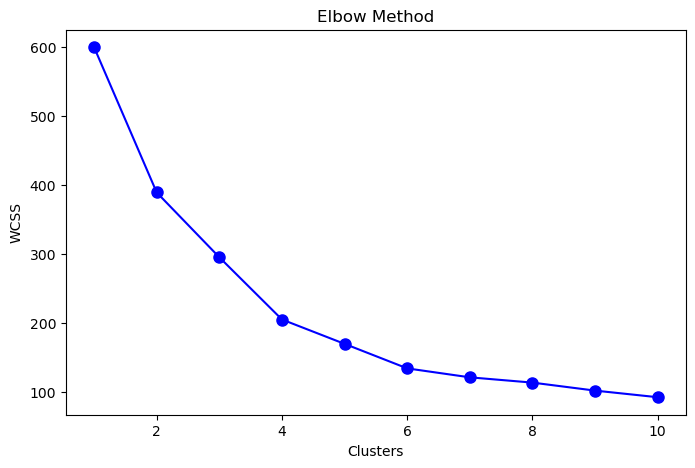

Optimal clusters by Elbow method: 4
Silhouette Scores:
Clusters: 2, Silhouette Score: 0.335
Clusters: 3, Silhouette Score: 0.358
Clusters: 4, Silhouette Score: 0.404
Clusters: 5, Silhouette Score: 0.408
Clusters: 6, Silhouette Score: 0.431


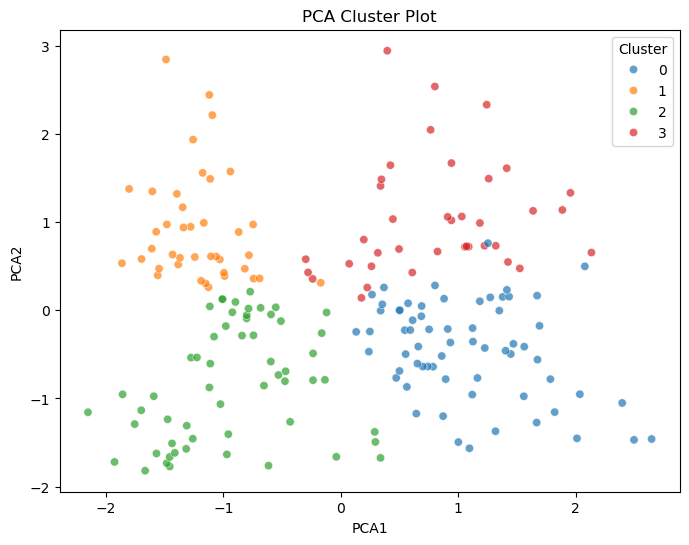

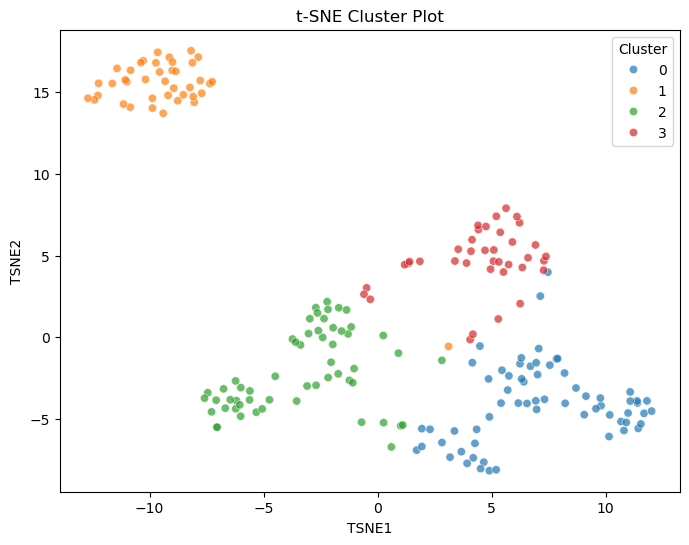

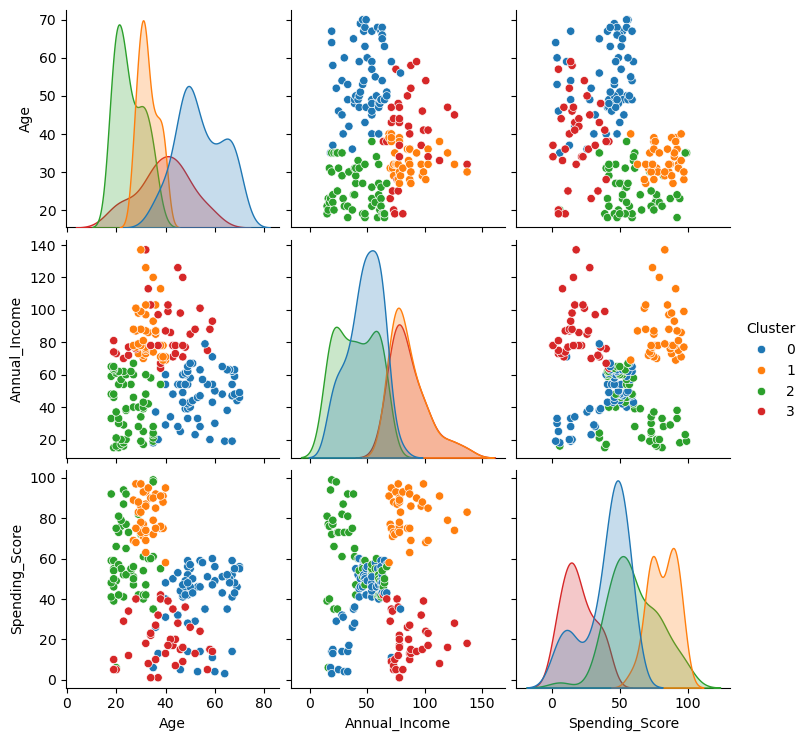

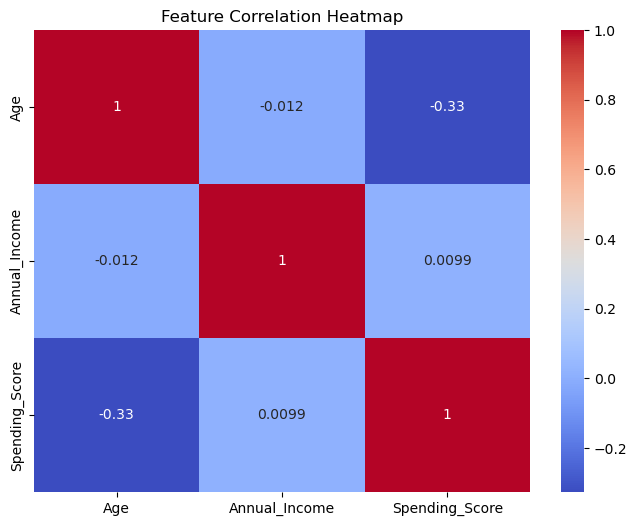


Cluster Insights:

--- Cluster 0 ---
Customers: 65
Avg Age: 54.0
Avg Income: 47.7k$
Avg Spending: 40.0
Moderate/low spenders – target for promotions.
Older customers – loyalty programs.

--- Cluster 1 ---
Customers: 40
Avg Age: 32.9
Avg Income: 86.1k$
Avg Spending: 81.5
High spenders – target for premium offers.
Older customers – loyalty programs.

--- Cluster 2 ---
Customers: 57
Avg Age: 25.4
Avg Income: 40.0k$
Avg Spending: 60.3
High spenders – target for premium offers.
Younger customers – digital campaigns.

--- Cluster 3 ---
Customers: 38
Avg Age: 39.4
Avg Income: 86.5k$
Avg Spending: 19.6
Moderate/low spenders – target for promotions.
Older customers – loyalty programs.
Dataset saved as Mall_Customers_Advanced_Segmented.csv


In [4]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from kneed import KneeLocator
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Step 2: Load and inspect dataset
def load_data(filepath):
    df = pd.read_csv(filepath)
    df.rename(columns={
        'Annual Income (k$)': 'Annual_Income',
        'Spending Score (1-100)': 'Spending_Score',
        'CustomerID': 'Customer_ID',
        'Genre': 'Gender'
    }, inplace=True)
    print("Dataset loaded. Shape:", df.shape)
    print("Missing values:\n", df.isnull().sum())
    print("Duplicates:", df.duplicated().sum())
    print("Data types:\n", df.dtypes)
    print("Summary:\n", df.describe())
    return df

# Step 3: Feature Engineering
def create_age_groups(df):
    bins = [0, 25, 45, 65, 100]
    labels = ['Young', 'Adult', 'Mid-Age', 'Senior']
    df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
    return df

def create_income_groups(df):
    bins = [0, 40, 70, 100, np.inf]
    labels = ['Low', 'Medium', 'High', 'Very High']
    df['Income_Group'] = pd.cut(df['Annual_Income'], bins=bins, labels=labels)
    return df

# Step 4: Scaling
def scale_features(df, features, method='standard'):
    if method == 'minmax':
        scaler = MinMaxScaler()
    elif method == 'robust':
        scaler = RobustScaler()
    else:
        scaler = StandardScaler()
    scaled = scaler.fit_transform(df[features])
    return scaled, scaler

# Step 5: Determine optimal clusters
def find_optimal_clusters(scaled_features):
    wcss = []
    for k in range(1, 11):
        km = KMeans(n_clusters=k, random_state=42)
        km.fit(scaled_features)
        wcss.append(km.inertia_)
    plt.figure(figsize=(8,5))
    plt.plot(range(1, 11), wcss, 'bo-', markersize=8)
    plt.xlabel('Clusters')
    plt.ylabel('WCSS')
    plt.title('Elbow Method')
    plt.show()
    kneedle = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
    optimal_k = kneedle.knee
    print("Optimal clusters by Elbow method:", optimal_k)
    return optimal_k

def silhouette_analysis(scaled_features):
    print("Silhouette Scores:")
    for k in range(2, 7):
        km = KMeans(n_clusters=k, random_state=42)
        preds = km.fit_predict(scaled_features)
        score = silhouette_score(scaled_features, preds)
        print(f"Clusters: {k}, Silhouette Score: {score:.3f}")

# Step 6: Apply Clustering
def apply_kmeans(scaled_features, df, n_clusters):
    km = KMeans(n_clusters=n_clusters, random_state=42)
    labels = km.fit_predict(scaled_features)
    df['Cluster'] = labels
    joblib.dump(km, 'kmeans_model.pkl')  # Save model
    return df, km

def apply_agglomerative(scaled_features, df, n_clusters):
    agg = AgglomerativeClustering(n_clusters=n_clusters)
    df['AggCluster'] = agg.fit_predict(scaled_features)
    return df

def apply_dbscan(scaled_features, df, eps=0.5, min_samples=5):
    db = DBSCAN(eps=eps, min_samples=min_samples)
    df['DBSCAN'] = db.fit_predict(scaled_features)
    return df

# Step 7: Dimensionality Reduction
def pca_transform(scaled_features):
    pca = PCA(n_components=2)
    result = pca.fit_transform(scaled_features)
    return result

def tsne_transform(scaled_features):
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    result = tsne.fit_transform(scaled_features)
    return result

# Step 8: Visualizations
def plot_clusters(df, x, y, cluster_label, title):
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=x, y=y, hue=cluster_label, palette='tab10', data=df, alpha=0.7)
    plt.title(title)
    plt.show()

def plot_pairplot(df, features, cluster_label):
    sns.pairplot(df, vars=features, hue=cluster_label, palette='tab10')
    plt.show()

def plot_heatmap(df, features):
    plt.figure(figsize=(8,6))
    sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm')
    plt.title('Feature Correlation Heatmap')
    plt.show()

# Step 9: Insights
def cluster_insights(df, n_clusters):
    print("\nCluster Insights:")
    for i in range(n_clusters):
        cluster = df[df['Cluster'] == i]
        print(f"\n--- Cluster {i} ---")
        print(f"Customers: {cluster.shape[0]}")
        print(f"Avg Age: {cluster['Age'].mean():.1f}")
        print(f"Avg Income: {cluster['Annual_Income'].mean():.1f}k$")
        print(f"Avg Spending: {cluster['Spending_Score'].mean():.1f}")
        if cluster['Spending_Score'].mean() > df['Spending_Score'].mean():
            print("High spenders – target for premium offers.")
        else:
            print("Moderate/low spenders – target for promotions.")
        if cluster['Age'].mean() < df['Age'].quantile(0.33):
            print("Younger customers – digital campaigns.")
        else:
            print("Older customers – loyalty programs.")

# Step 10: Save dataset
def save_dataset(df, filename):
    df.to_csv(filename, index=False)
    print(f"Dataset saved as {filename}")

# Main Execution Flow
if __name__ == "__main__":
    df = load_data(r"C:\Users\Mahendra\Downloads\archive\Mall_Customers.csv")
    df = create_age_groups(df)
    df = create_income_groups(df)
    features = ['Age', 'Annual_Income', 'Spending_Score']
    scaled_features, scaler = scale_features(df, features, method='standard')
    optimal_k = find_optimal_clusters(scaled_features)
    silhouette_analysis(scaled_features)
    df, kmeans_model = apply_kmeans(scaled_features, df, optimal_k)
    df = apply_agglomerative(scaled_features, df, optimal_k)
    df = apply_dbscan(scaled_features, df, eps=0.6, min_samples=5)
    pca_result = pca_transform(scaled_features)
    df['PCA1'], df['PCA2'] = pca_result[:,0], pca_result[:,1]
    tsne_result = tsne_transform(scaled_features)
    df['TSNE1'], df['TSNE2'] = tsne_result[:,0], tsne_result[:,1]
    plot_clusters(df, 'PCA1', 'PCA2', 'Cluster', 'PCA Cluster Plot')
    plot_clusters(df, 'TSNE1', 'TSNE2', 'Cluster', 't-SNE Cluster Plot')
    plot_pairplot(df, features, 'Cluster')
    plot_heatmap(df, features)
    cluster_insights(df, optimal_k)
    save_dataset(df, 'Mall_Customers_Advanced_Segmented.csv')
